In [8]:
sip["month"] = pd.to_datetime(
    sip["month"]
)

fig = px.line(

    sip,

    x="month",

    y="sip_inflow_crore",

    title="Monthly SIP Inflow Trend"

)

max_row = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

fig.add_annotation(

    x=max_row["month"],

    y=max_row["sip_inflow_crore"],

    text="All Time High",

    showarrow=True

)

fig.show()

In [25]:
print(
    category.columns
)

print(
    category.head()
)

Index(['month', 'category', 'net_inflow_crore'], dtype='str')
     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


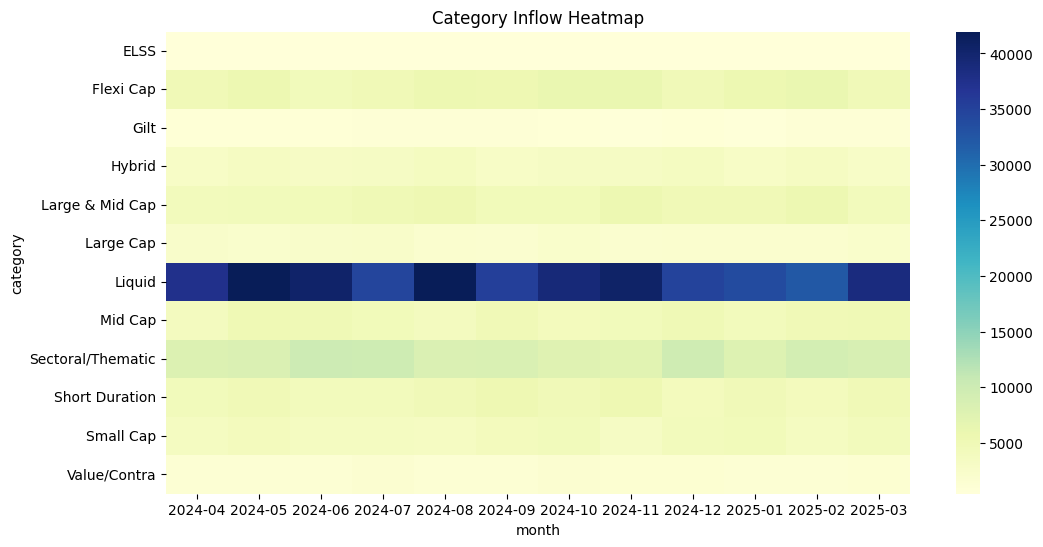

In [10]:
category["month"] = pd.to_datetime(
    category["month"]
)

category["month"] = (
    category["month"]
    .dt.strftime("%Y-%m")
)

heatmap_data = category.pivot(

    index="category",

    columns="month",

    values="net_inflow_crore"

)

plt.figure(
    figsize=(12,6)
)

sns.heatmap(

    heatmap_data,

    cmap="YlGnBu"

)

plt.title(
    "Category Inflow Heatmap"
)

plt.show()

In [11]:
age_counts = transactions[
    "age_group"
].value_counts()

fig = px.pie(

    values=age_counts.values,

    names=age_counts.index,

    title="Investor Age Group Distribution"

)

fig.show()

In [12]:
gender_counts = transactions[
    "gender"
].value_counts()

fig = px.pie(

    values=gender_counts.values,

    names=gender_counts.index,

    title="Gender Distribution"

)

fig.show()

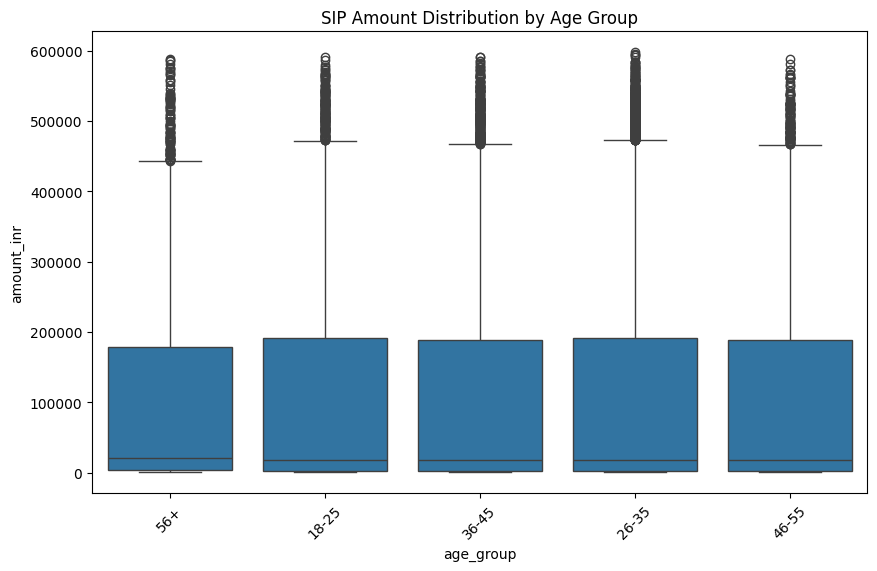

In [13]:
plt.figure(
    figsize=(10,6)
)

sns.boxplot(

    data=transactions,

    x="age_group",

    y="amount_inr"

)

plt.title(
    "SIP Amount Distribution by Age Group"
)

plt.xticks(
    rotation=45
)

plt.show()

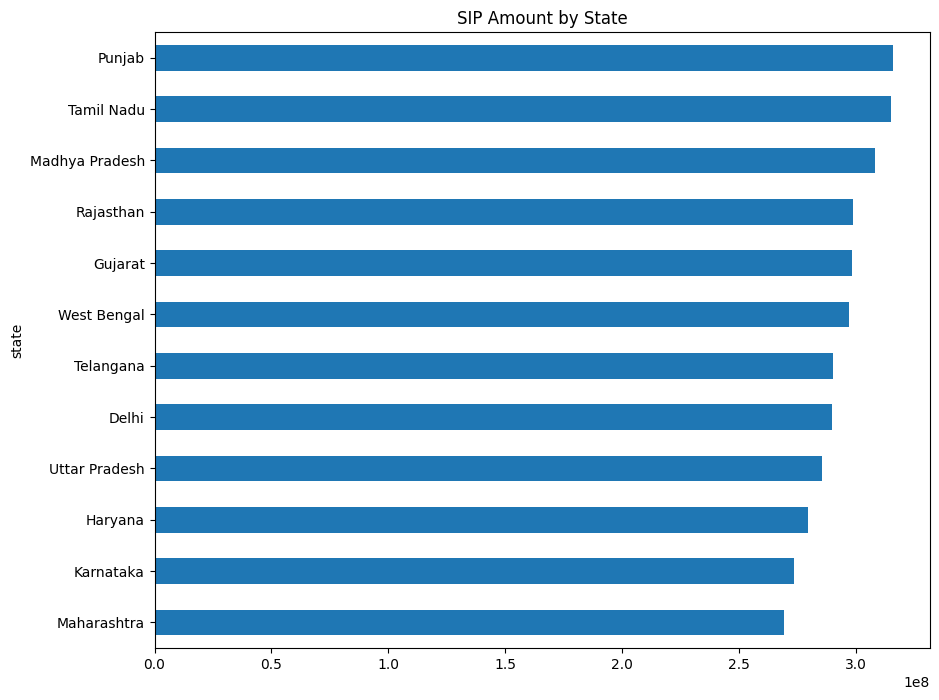

In [14]:
state_data = transactions.groupby(
    "state"
)["amount_inr"].sum().sort_values()

plt.figure(
    figsize=(10,8)
)

state_data.plot(
    kind="barh"
)

plt.title(
    "SIP Amount by State"
)

plt.show()

In [15]:
city_counts = transactions[
    "city_tier"
].value_counts()

fig = px.pie(

    values=city_counts.values,

    names=city_counts.index,

    title="T30 vs B30 Distribution"

)

fig.show()

In [16]:
print(
    folio.columns
)

print(
    folio.head()
)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


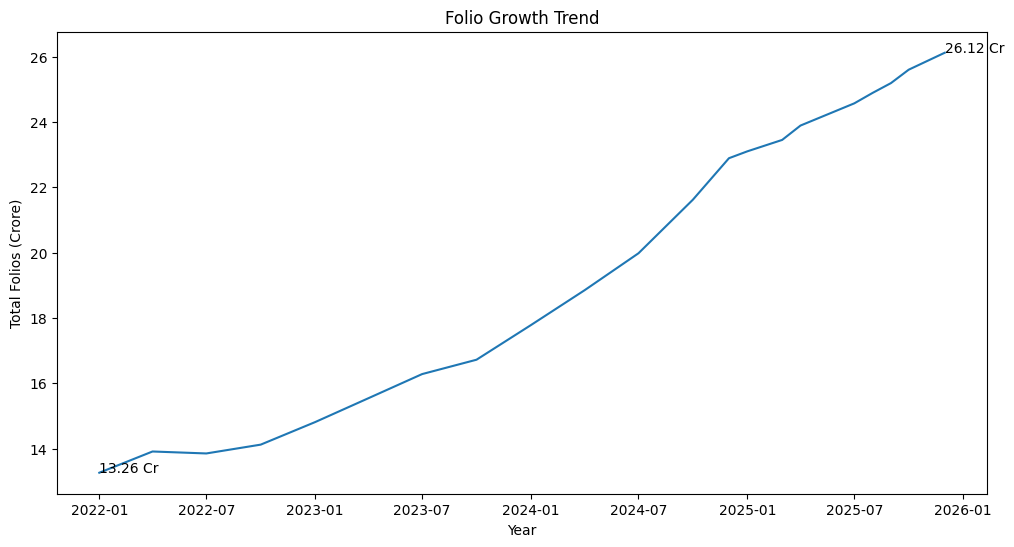

In [17]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

plt.figure(
    figsize=(12,6)
)

plt.plot(

    folio["month"],

    folio["total_folios_crore"]

)

plt.title(
    "Folio Growth Trend"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Total Folios (Crore)"
)

plt.annotate(

    "13.26 Cr",

    xy=(
        folio["month"].iloc[0],
        folio["total_folios_crore"].iloc[0]
    )

)

plt.annotate(

    "26.12 Cr",

    xy=(
        folio["month"].iloc[-1],
        folio["total_folios_crore"].iloc[-1]
    )

)

plt.show()

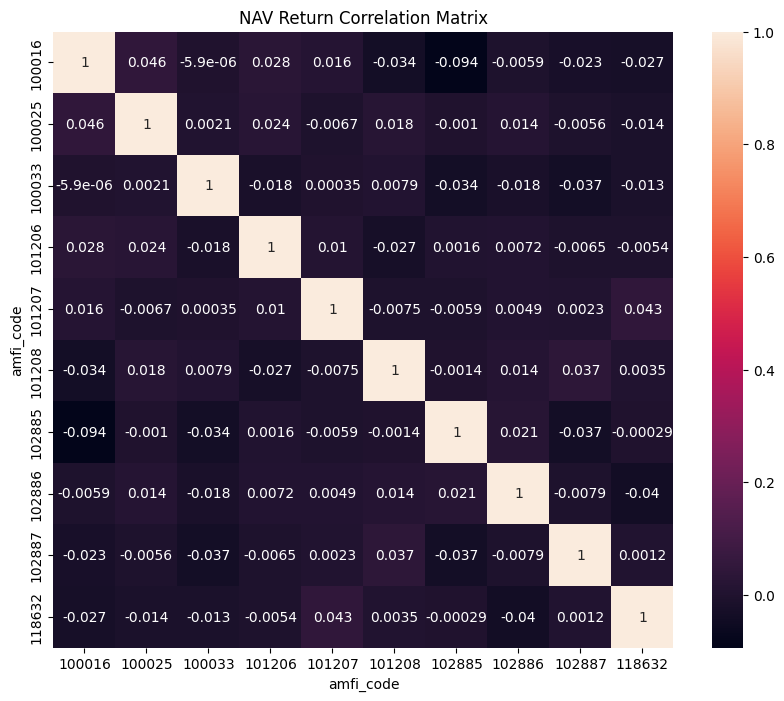

In [18]:
selected = nav[
    nav["amfi_code"].isin(
        nav["amfi_code"].unique()[:10]
    )
]

pivot_nav = selected.pivot(

    index="date",

    columns="amfi_code",

    values="nav"

)

returns = pivot_nav.pct_change()

corr = returns.corr()

plt.figure(
    figsize=(10,8)
)

sns.heatmap(

    corr,

    annot=True

)

plt.title(
    "NAV Return Correlation Matrix"
)

plt.show()

In [19]:
print(
    portfolio.columns
)

print(
    portfolio.head()
)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


In [20]:
sector_data = portfolio.groupby(
    "sector"
)["weight_pct"].sum()

fig = px.pie(

    values=sector_data.values,

    names=sector_data.index,

    hole=0.5,

    title="Sector Allocation Distribution"

)

fig.show()

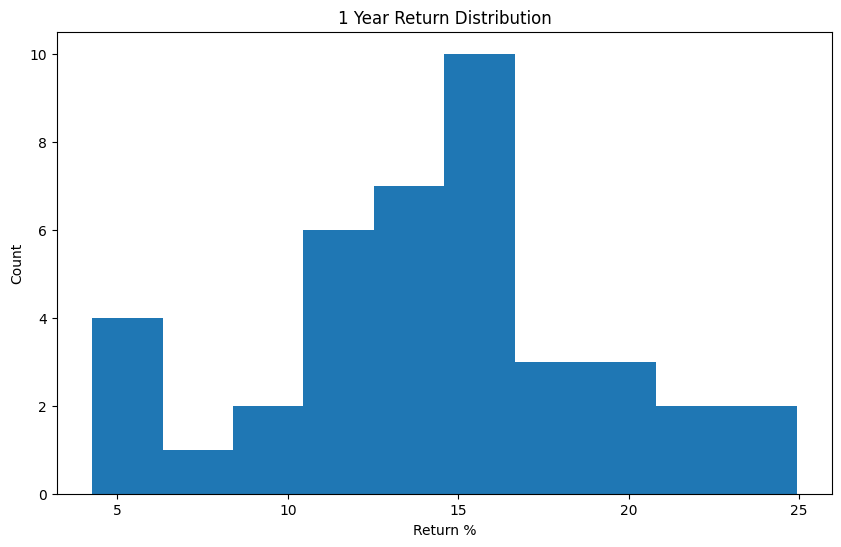

In [21]:
plt.figure(
    figsize=(10,6)
)

plt.hist(

    performance[
        "return_1yr_pct"
    ],

    bins=10

)

plt.title(
    "1 Year Return Distribution"
)

plt.xlabel(
    "Return %"
)

plt.ylabel(
    "Count"
)

plt.show()

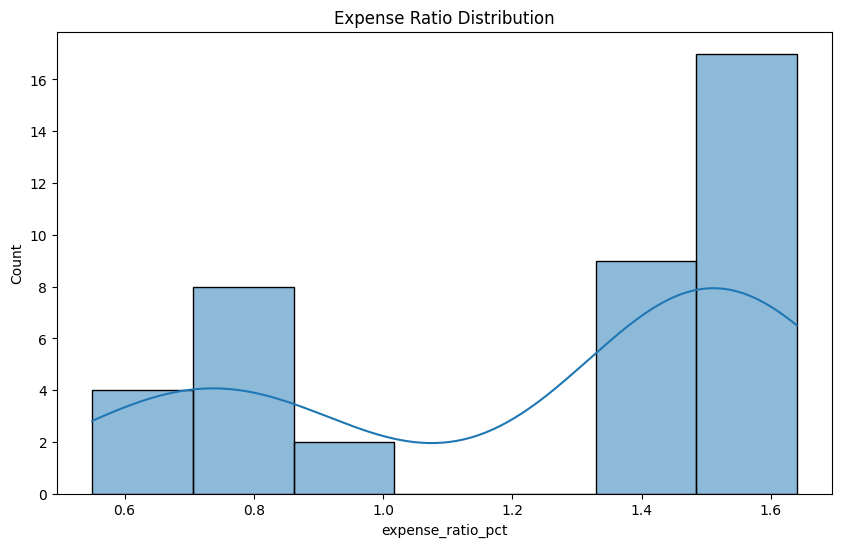

In [22]:
plt.figure(
    figsize=(10,6)
)

sns.histplot(

    performance[
        "expense_ratio_pct"
    ],

    kde=True

)

plt.title(
    "Expense Ratio Distribution"
)

plt.show()

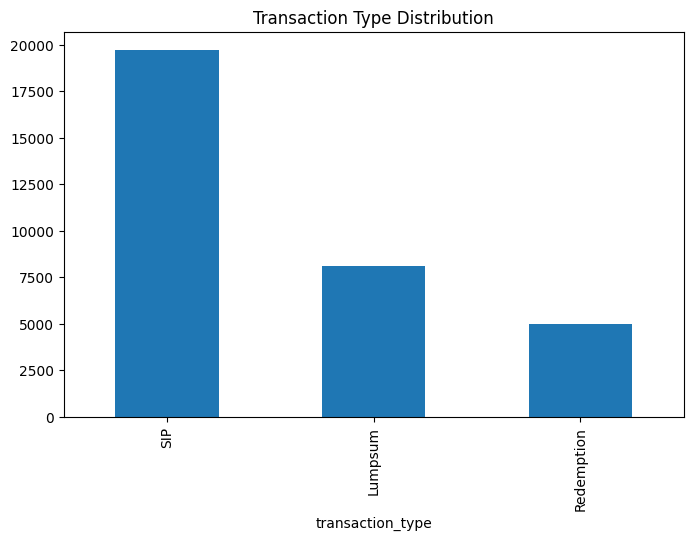

In [23]:
tx_counts = transactions[
    "transaction_type"
].value_counts()

plt.figure(
    figsize=(8,5)
)

tx_counts.plot(
    kind="bar"
)

plt.title(
    "Transaction Type Distribution"
)

plt.show()

In [24]:
risk = performance[
    "risk_grade"
].value_counts()

fig = px.bar(

    x=risk.index,

    y=risk.values,

    title="Risk Grade Distribution"

)

fig.show()

### Insight 1

NAV values generally show upward movement during 2023 indicating strong market growth.

### Insight 2

AUM growth shows large fund houses dominating the market with higher asset concentration.

In [7]:
print(
    sip.columns
)

print(
    sip.head()
)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


### Insight 3

SIP inflows show continuous increase indicating growing retail participation.

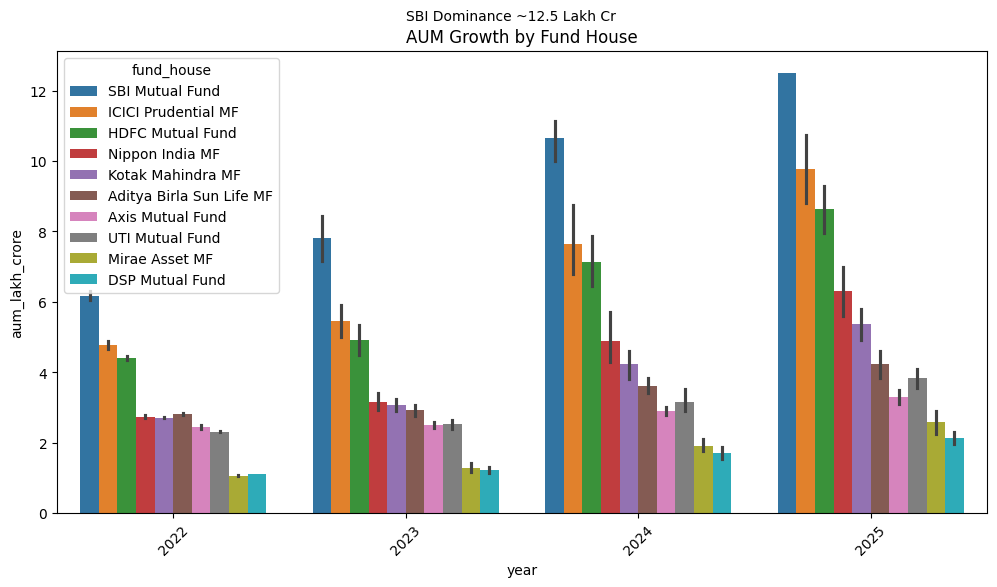

In [6]:
aum["date"] = pd.to_datetime(
    aum["date"]
)

aum["year"] = aum[
    "date"
].dt.year

plt.figure(
    figsize=(12,6)
)

sns.barplot(

    data=aum,

    x="year",

    y="aum_lakh_crore",

    hue="fund_house"

)

plt.title(
    "AUM Growth by Fund House"
)

plt.xticks(
    rotation=45
)

plt.annotate(

    "SBI Dominance ~12.5 Lakh Cr",

    xy=(1,12.5),

    xytext=(1,14)

)

plt.show()

### Insight 4

Certain categories consistently attract higher inflows than others.

In [5]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


### Insight 5

Young and middle age investors contribute major transaction volume.

In [4]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

top_funds = nav[
    "amfi_code"
].unique()[:10]

nav_subset = nav[
    nav["amfi_code"].isin(
        top_funds
    )
]

fig = px.line(

    nav_subset,

    x="date",

    y="nav",

    color="amfi_code",

    title="Daily NAV Trend (2022-2026)"

)

fig.add_vrect(

    x0="2023-01-01",

    x1="2023-12-31",

    annotation_text="2023 Bull Run",

    opacity=0.15

)

fig.add_vrect(

    x0="2024-01-01",

    x1="2024-12-31",

    annotation_text="2024 Corrections",

    opacity=0.15

)

fig.show()

### Insight 6

Transaction amounts vary significantly across age groups.

In [3]:
print("Fund:",fund.shape)

print("NAV:",nav.shape)

print("AUM:",aum.shape)

print("Transactions:",transactions.shape)

print("Performance:",performance.shape)

Fund: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
Transactions: (32778, 13)
Performance: (40, 19)


### Insight 7

Few states contribute larger investment volumes compared to others.

In [2]:
fund = pd.read_csv(
    "../Data/raw/01_fund_master.csv"
)

nav = pd.read_csv(
    "../Data/processed/nav_history_cleaned.csv"
)

aum = pd.read_csv(
    "../Data/raw/03_aum_by_fund_house.csv"
)

sip = pd.read_csv(
    "../Data/raw/04_monthly_sip_inflows.csv"
)

category = pd.read_csv(
    "../Data/raw/05_category_inflows.csv"
)

folio = pd.read_csv(
    "../Data/raw/06_industry_folio_count.csv"
)

performance = pd.read_csv(
    "../Data/processed/scheme_performance_cleaned.csv"
)

transactions = pd.read_csv(
    "../Data/processed/investor_transactions_cleaned.csv"
)

portfolio = pd.read_csv(
    "../Data/raw/09_portfolio_holdings.csv"
)

print("Loaded Successfully")

Loaded Successfully


### Insight 8

Folio counts show strong long term growth from 2022 onwards.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

import plotly.express as px

import plotly.graph_objects as go

print("Libraries Loaded")

Matplotlib is building the font cache; this may take a moment.


Libraries Loaded


### Insight 9

Many selected funds exhibit positive correlation in returns.

### Insight 10

Banking and large sectors contribute major portfolio allocation.